# Agency & Client Insights EDA

### Data



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

agency = pd.read_csv('../clean_data/combined_agency.csv')

agency['month'] = pd.to_datetime(agency['month'])
agency = agency.sort_values('month').reset_index(drop=True)

print("Agency data shape:", agency.shape)
agency.head()

Agency data shape: (4491, 22)


,month,visited_agency,total_visits,total_people_served,unique_clients,unique_clients_excl_unknown,unique_households,unique_households_excl_unknown,avg_household_size,avg_client_age,...,31-44,45-64,65+,Not Reported,ow_cases_official,ow_beneficiaries,odsp_cases_official,odsp_beneficiaries,total_homeless,total_chronic_homeless
0,2015-01-01,Blessed Sacrament Catholic Church - Society of...,108,344,108,78,108,78,3.185185,46.102564,...,28,34,7,30,8257,14896,10998,15022,NaN,NaN
1,2015-01-01,Cambridge Food Bank - Cambridge,1630,1630,1097,1097,1076,1076,1.000000,41.241537,...,519,618,43,7,8257,14896,10998,15022,NaN,NaN
2,2015-01-01,Ray of Hope,126,231,123,122,122,121,1.811475,45.606557,...,42,58,7,1,8257,14896,10998,15022,NaN,NaN
3,2015-02-01,Blessed Sacrament Catholic Church - Society of...,106,319,106,86,106,86,3.009434,44.616279,...,29,35,7,20,8270,14928,11000,15052,NaN,NaN
4,2015-02-01,Cambridge Food Bank - Cambridge,1386,1386,1050,1050,1034,1034,1.000000,41.149952,...,458,513,38,4,8270,14928,11000,15052,NaN,NaN


### Agency Overview

In [7]:
print("Unique agencies:", agency['visited_agency'].nunique())
print("Months covered:", agency['month'].nunique())
print("Date range:", agency['month'].min(), "→", agency['month'].max())
print("Total observations:", len(agency))

Unique agencies: 61
Months covered: 138
Date range: 2015-01-01 00:00:00 → 2026-06-01 00:00:00
Total observations: 4491


### Reporting Frequency

count     61.000000
mean      73.622951
std       46.631950
min        3.000000
25%       36.000000
50%       65.000000
75%      124.000000
max      138.000000
dtype: float64


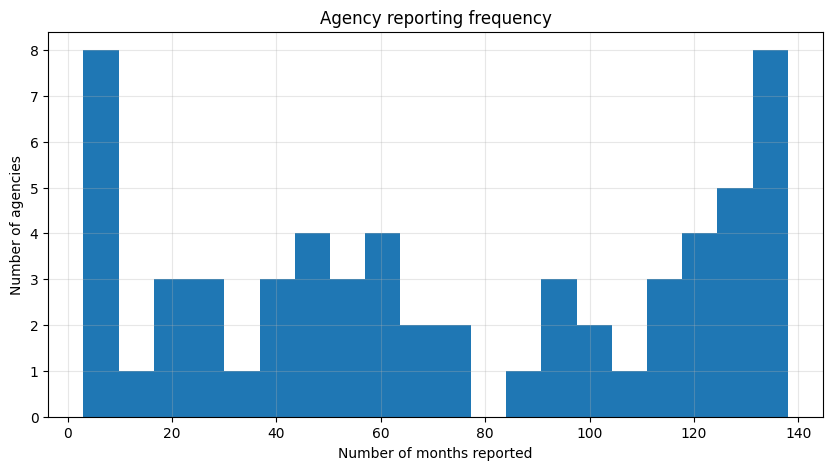

In [9]:
agency_reporting = (
    agency.groupby('visited_agency')
          .size()
          .sort_values(ascending=False)
)

print(agency_reporting.describe())

plt.figure(figsize=(10,5))

plt.hist(
    agency_reporting,
    bins=20
)

plt.xlabel("Number of months reported")
plt.ylabel("Number of agencies")
plt.title("Agency reporting frequency")

plt.grid(alpha=0.3)
plt.show()


### Reporting Coverage Over Time

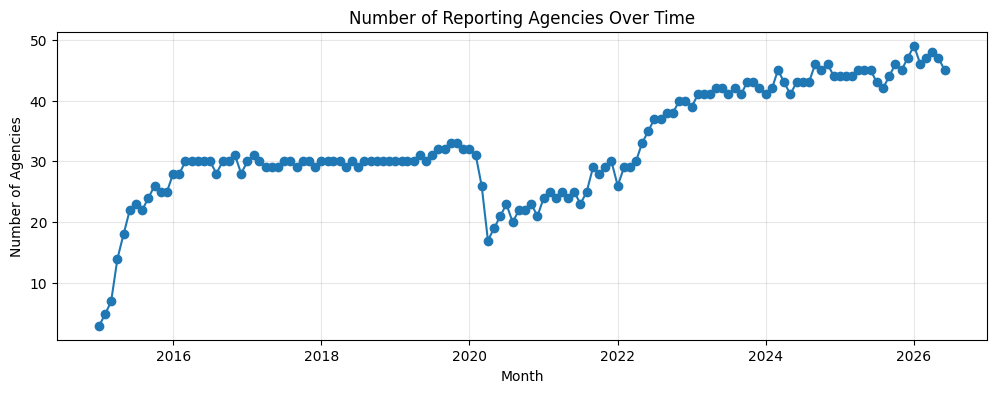

In [10]:
monthly_reporting = (
    agency.groupby('month')
          ['visited_agency']
          .nunique()
)

plt.figure(figsize=(12,4))

plt.plot(
    monthly_reporting.index,
    monthly_reporting.values,
    marker='o'
)

plt.title("Number of Reporting Agencies Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Agencies")

plt.grid(alpha=0.3)
plt.show()

Clear expansion of the reporting network

### Agency Demand Ranking

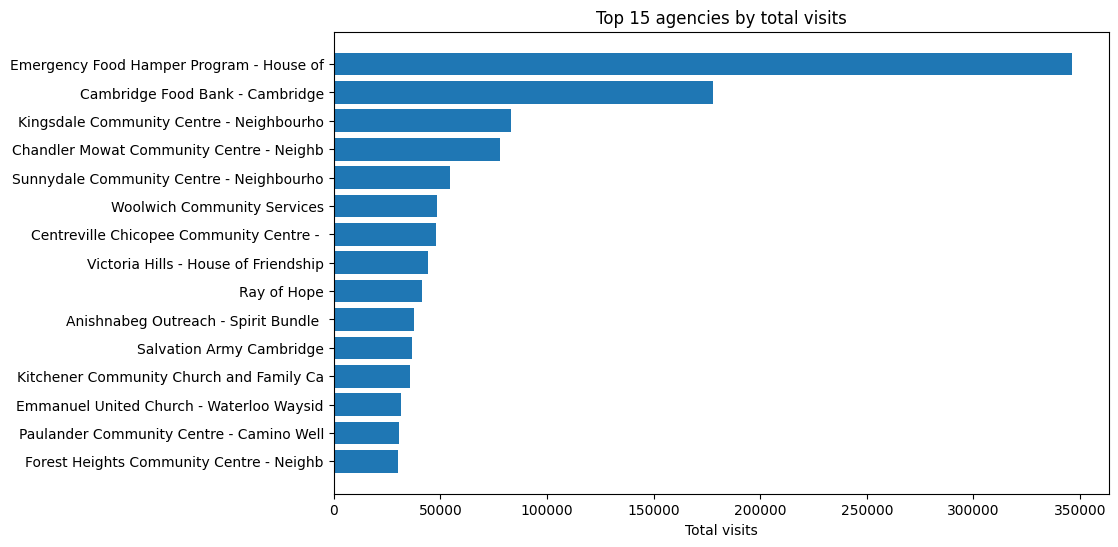

In [12]:
agency_volume = (
    agency.groupby('visited_agency')
          ['total_visits']
          .sum()
          .sort_values(ascending=False)
)

agency_volume.head(15)

top15 = agency_volume.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    range(len(top15)),
    top15.values
)

plt.yticks(
    range(len(top15)),
    [x[:40] for x in top15.index]
)

plt.gca().invert_yaxis()

plt.xlabel("Total visits")
plt.title("Top 15 agencies by total visits")

plt.show()

Demand is concentrated amongst these agencies. Emergency Food Hamper program accounts for a disproportionate share of total visits

### Agency Average Demand and Variability

In [14]:
agency_stats = (
    agency.groupby('visited_agency')
          .agg(
              avg_monthly_visits=('total_visits','mean'),
              variability=('total_visits','std'),
              months=('month','count')
          )
)

agency_stats['coefficient_variation'] = (
    agency_stats['variability'] /
    agency_stats['avg_monthly_visits']
)

agency_stats.sort_values(
    'coefficient_variation',
    ascending=False
).head(10)

,avg_monthly_visits,variability,months,coefficient_variation
visited_agency,,,,
The Food Bank of Waterloo Region - Kitchener,88.545455,101.930226,55,1.151163
The Healing of the Seven Generations,15.500000,16.932218,6,1.092401
Woolwich Community Services,355.095588,371.662768,136,1.046656
Southwood Resource Centre - Kinbridge Community Association,9.967391,10.077121,92,1.011009
Langs,28.525862,27.764996,116,0.973327
University of Waterloo Food Bank,84.714286,74.263304,42,0.876633
Cambridge Shelter Corporation - Bridges,2.000000,1.732051,3,0.866025
Emmanuel United Church - Waterloo Wayside,240.954198,186.523328,131,0.774103
Cambridge Vineyard - Urban Hope,39.250000,30.298868,36,0.771946


### Most Volatile Agencies



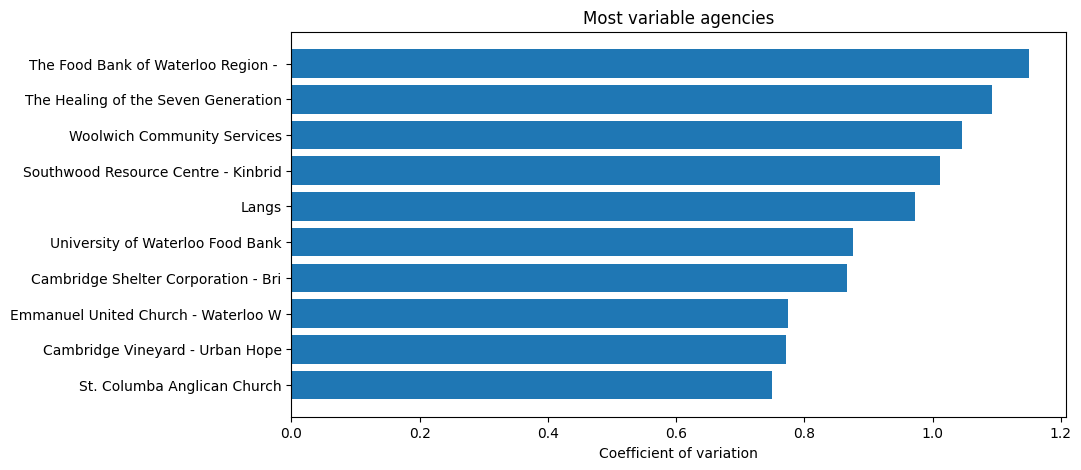

In [15]:
volatile = (
    agency_stats
    .sort_values(
        'coefficient_variation',
        ascending=False
    )
    .head(10)
)


plt.figure(figsize=(10,5))

plt.barh(
    range(len(volatile)),
    volatile['coefficient_variation']
)

plt.yticks(
    range(len(volatile)),
    [x[:35] for x in volatile.index]
)

plt.gca().invert_yaxis()

plt.xlabel("Coefficient of variation")
plt.title("Most variable agencies")

plt.show()

### Agency Demographic Profiles


In [16]:
age_cols = [
    '0-17',
    '18-30',
    '31-44',
    '45-64',
    '65+'
]


agency_demo = (
    agency.groupby('visited_agency')[age_cols]
          .sum()
)


agency_demo_pct = (
    agency_demo
    .div(
        agency_demo.sum(axis=1),
        axis=0
    )
    *100
)


agency_demo_pct.head()

,0-17,18-30,31-44,45-64,65+
visited_agency,,,,,
All Saints' Anglican Church,0.347222,15.039062,44.205729,37.131076,3.276910
Anishnabeg Outreach - Spirit Bundle,0.000000,0.000000,100.000000,0.000000,0.000000
Base Church,0.384369,10.954516,43.882127,32.671365,12.107623
Blessed Sacrament Catholic Church - Society of St. Vincent de Paul,0.066912,15.255938,35.931750,42.974239,5.771161
Cambridge Food Bank - Cambridge,0.314762,17.775304,33.402653,39.649862,8.857419


### Age Distribution over Time

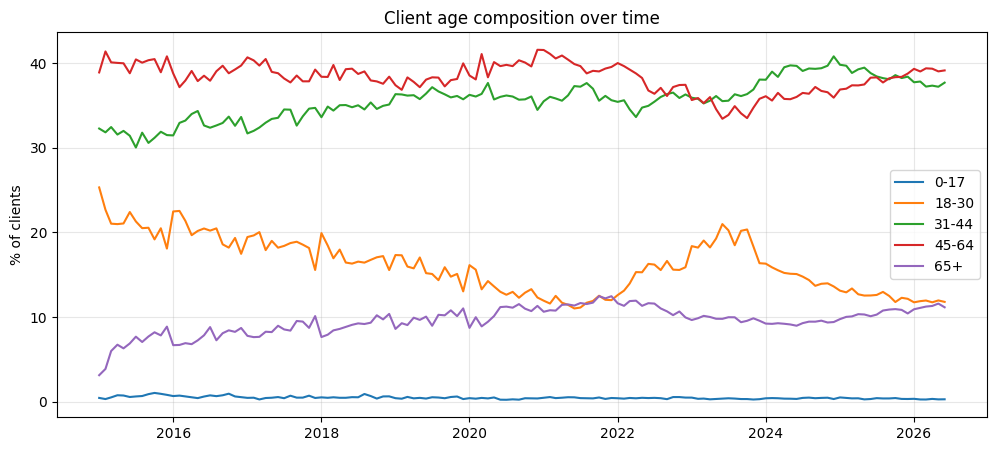

In [17]:
age_time = (
    agency.groupby('month')[age_cols]
          .sum()
)


age_time_pct = (
    age_time
    .div(
        age_time.sum(axis=1),
        axis=0
    )
    *100
)


plt.figure(figsize=(12,5))

for col in age_cols:
    plt.plot(
        age_time_pct.index,
        age_time_pct[col],
        label=col
    )


plt.title("Client age composition over time")
plt.ylabel("% of clients")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Theres been a steady increase in clients between the ages of 45-64 visiting the food bank. Other age groups stay relatively the same.

### Largest Single Agency Month Demand Events

In [18]:
largest_events = (
    agency[['month',
            'visited_agency',
            'total_visits']]
    .sort_values(
        'total_visits',
        ascending=False
    )
    .head(20)
)

largest_events

,month,visited_agency,total_visits
4196,2025-12-01,Emergency Food Hamper Program - House of Frien...,4712
3054,2023-10-01,Emergency Food Hamper Program - House of Frien...,4205
3012,2023-09-01,Emergency Food Hamper Program - House of Frien...,3966
3097,2023-11-01,Emergency Food Hamper Program - House of Frien...,3796
4337,2026-03-01,Emergency Food Hamper Program - House of Frien...,3794
4384,2026-04-01,Emergency Food Hamper Program - House of Frien...,3723
4104,2025-10-01,Emergency Food Hamper Program - House of Frien...,3696
3353,2024-05-01,Emergency Food Hamper Program - House of Frien...,3674
4432,2026-05-01,Emergency Food Hamper Program - House of Frien...,3657
4149,2025-11-01,Emergency Food Hamper Program - House of Frien...,3627


### Agency Summary Table

In [19]:
summary = (
    agency.groupby('visited_agency')
          .agg(
              total_visits=('total_visits','sum'),
              avg_visits=('total_visits','mean'),
              months_reporting=('month','count'),
              avg_age=('avg_client_age','mean'),
              avg_household_size=('avg_household_size','mean')
          )
          .sort_values(
              'total_visits',
              ascending=False
          )
)

summary.head(15)

,total_visits,avg_visits,months_reporting,avg_age,avg_household_size
visited_agency,,,,,
Emergency Food Hamper Program - House of Friendship,346123,2526.445255,137,43.413096,3.009937
Cambridge Food Bank - Cambridge,178043,1290.166667,138,44.343255,2.171200
Kingsdale Community Centre - Neighbourhood Food Program - House of Friendship,83161,607.014599,137,46.185805,2.826171
Chandler Mowat Community Centre - Neighbourhood Food Program - House of Friendship,78134,601.030769,130,43.435404,3.360208
Sunnydale Community Centre - Neighbourhood Food Program - House of Friendship,54380,408.872180,133,43.223854,3.897296
Woolwich Community Services,48293,355.095588,136,47.056037,2.592145
Centreville Chicopee Community Centre - Neighbourhood Food Program - House of Friendship,48057,624.116883,77,44.533564,3.155736
Victoria Hills - House of Friendship,44223,680.353846,65,43.739653,3.348639
Ray of Hope,41224,305.362963,135,46.766865,2.490315
